# Trabajo Práctico N°2 — Validación del Modelo

**Alumno:** Gonzalo Zarazaga

---

Este notebook profundiza en el comportamiento del modelo XGBoost entrenado en `04_entrenamiento_y_optimizacion.ipynb`.

**Objetivos:**
1. Identificar cuáles son los atributos más relevantes y analizar cómo se distribuyen en fumadores vs no fumadores
2. Visualizar las probabilidades predichas por el modelo sobre train y test
3. Explorar si un ajuste del umbral de decisión mejora el F1-Score

**Insumo:** `models/xgboost_optimized.joblib` · `data/processed/smoking_train_processed.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import xgboost as xgb
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    auc
)

PATH_PROC   = Path("../data/processed")
PATH_MODELS = Path("../models")

RANDOM_STATE = 42
TEST_SIZE    = 0.2

## 1. Carga del modelo y los datos

In [2]:
df = pd.read_csv(PATH_PROC / "smoking_train_processed.csv")
X  = df.drop(columns=["smoking"])
y  = df["smoking"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

model = joblib.load(PATH_MODELS / "xgboost_optimized.joblib")

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Modelo cargado: {type(model).__name__}")

Train: (40000, 24)  |  Test: (10000, 24)
Modelo cargado: XGBClassifier


## 2. Atributos más relevantes: importancia por **gain**

XGBoost ofrece varias métricas de importancia. La más recomendada es el **gain**:
la reducción promedio del error (función de pérdida) que aporta cada feature en los splits donde interviene.

### ¿Por qué gain y no weight?

- **Weight:** cuenta cuántas veces se usa cada feature en los splits de todos los árboles.
  Favorece features que el modelo usa frecuentemente aunque su aporte individual sea pequeño.
- **Gain:** mide el impacto real en la reducción del error. Un feature usado pocas veces
  pero en splits muy discriminativos (como la raíz del árbol) tiene gain alto.

> Para un predictor dominante como `gender`, weight puede ser engañoso:
> el modelo lo usa una sola vez por árbol (en la raíz, donde separa con máxima ganancia)
> pero esa única partición reduce el error más que cientos de splits sobre otras variables.

In [3]:
booster = model.get_booster()

# Gain normalizado — importancia recomendada para XGBoost
gain_scores = booster.get_score(importance_type="gain")
total_gain  = sum(gain_scores.values())
gain_norm   = pd.Series(
    {k: v / total_gain for k, v in gain_scores.items()},
    name="gain"
).reindex(X.columns, fill_value=0).sort_values(ascending=False)

# Weight normalizado — para comparación
weight_scores = booster.get_score(importance_type="weight")
total_weight  = sum(weight_scores.values())
weight_norm   = pd.Series(
    {k: v / total_weight for k, v in weight_scores.items()},
    name="weight"
).reindex(X.columns, fill_value=0)

print("=== Importancia por GAIN (recomendada) ===")
print(gain_norm.round(4).to_string())
print()
print("=== Top 5 por WEIGHT (solo para comparar) ===")
print(weight_norm.sort_values(ascending=False).head(5).round(4).to_string())

=== Importancia por GAIN (recomendada) ===
gender                 0.8079
height(cm)             0.0341
Gtp                    0.0161
hemoglobin             0.0159
tartar                 0.0112
age                    0.0112
dental caries          0.0102
serum creatinine       0.0088
triglyceride           0.0087
ALT                    0.0065
weight(kg)             0.0060
LDL                    0.0055
waist(cm)              0.0054
AST                    0.0054
eyesight(left)         0.0053
fasting blood sugar    0.0051
relaxation             0.0050
Cholesterol            0.0049
systolic               0.0048
HDL                    0.0048
eyesight(right)        0.0045
Urine protein          0.0044
hearing(left)          0.0043
hearing(right)         0.0039

=== Top 5 por WEIGHT (solo para comparar) ===
triglyceride    0.0894
Gtp             0.0798
HDL             0.0754
ALT             0.0697
systolic        0.0665


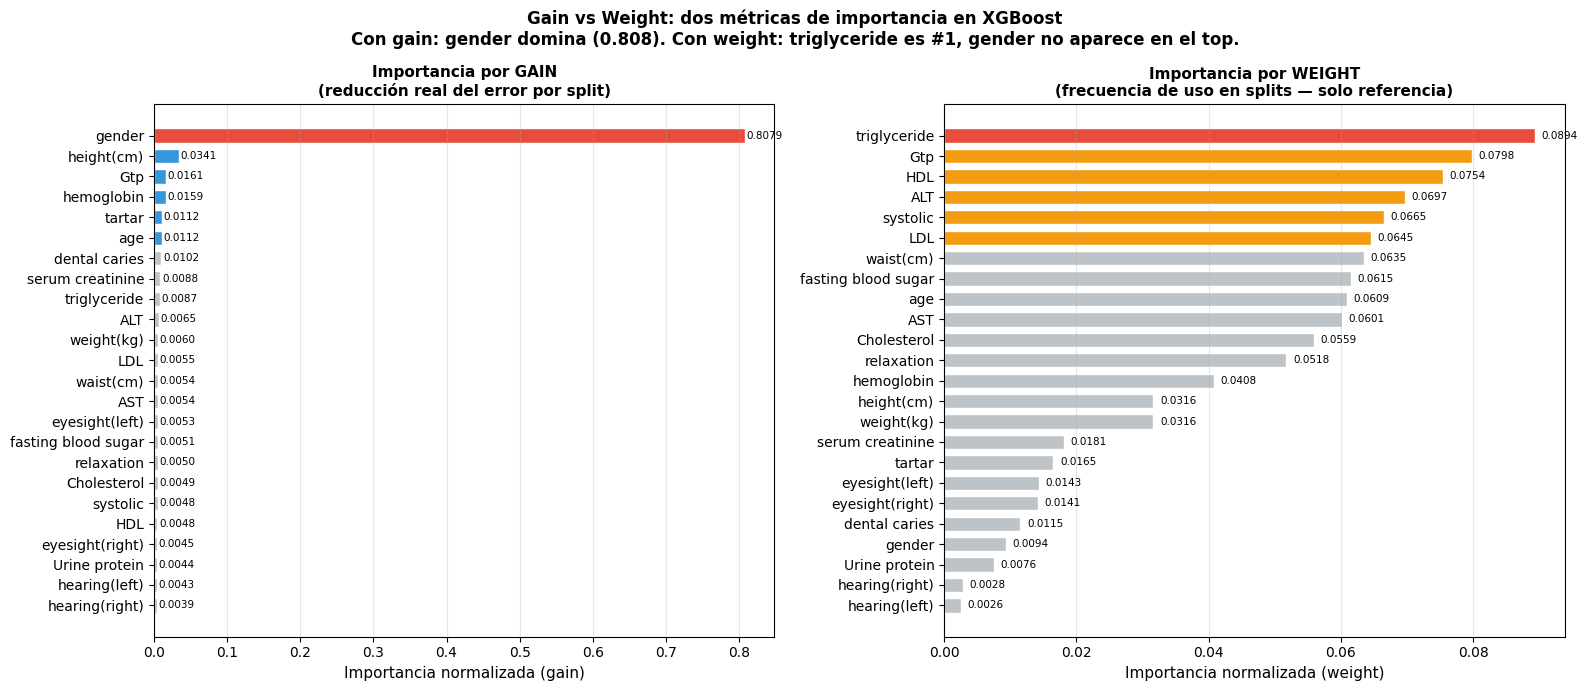

Rank #1 por GAIN:    gender (0.8079)
Rank #1 por WEIGHT:  triglyceride (0.0894)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Panel izquierdo: GAIN ---
colores_gain = [
    "#e74c3c" if imp == gain_norm.max() else
    "#3498db" if imp >= gain_norm.quantile(0.75) else
    "#bdc3c7"
    for imp in gain_norm.values
]
axes[0].barh(gain_norm.index[::-1], gain_norm.values[::-1],
             color=colores_gain[::-1], edgecolor="white", height=0.7)
for i, (val, name) in enumerate(zip(gain_norm.values[::-1], gain_norm.index[::-1])):
    if val > 0.001:
        axes[0].text(val + 0.002, i, f"{val:.4f}", va="center", ha="left", fontsize=7.5)
axes[0].set_xlabel("Importancia normalizada (gain)", fontsize=11)
axes[0].set_title("Importancia por GAIN\n(reducción real del error por split)",
                  fontsize=11, fontweight="bold")
axes[0].grid(axis="x", alpha=0.3)

# --- Panel derecho: WEIGHT ---
weight_sorted = weight_norm.sort_values(ascending=False)
colores_weight = [
    "#e74c3c" if imp == weight_sorted.max() else
    "#f39c12" if imp >= weight_sorted.quantile(0.75) else
    "#bdc3c7"
    for imp in weight_sorted.values
]
axes[1].barh(weight_sorted.index[::-1], weight_sorted.values[::-1],
             color=colores_weight[::-1], edgecolor="white", height=0.7)
for i, (val, name) in enumerate(zip(weight_sorted.values[::-1], weight_sorted.index[::-1])):
    if val > 0.001:
        axes[1].text(val + 0.001, i, f"{val:.4f}", va="center", ha="left", fontsize=7.5)
axes[1].set_xlabel("Importancia normalizada (weight)", fontsize=11)
axes[1].set_title("Importancia por WEIGHT\n(frecuencia de uso en splits — solo referencia)",
                  fontsize=11, fontweight="bold")
axes[1].grid(axis="x", alpha=0.3)

plt.suptitle(
    "Gain vs Weight: dos métricas de importancia en XGBoost\n"
    "Con gain: gender domina (0.808). Con weight: triglyceride es #1, gender no aparece en el top.",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()

print("Rank #1 por GAIN:   ", gain_norm.idxmax(), f"({gain_norm.max():.4f})")
print("Rank #1 por WEIGHT: ", weight_norm.idxmax(), f"({weight_norm.max():.4f})")

## 3. SHAP Values — explicabilidad del modelo

**SHAP (SHapley Additive exPlanations)** es una técnica de explicabilidad basada en teoría de juegos cooperativos.
Asigna a cada feature una contribución exacta a la predicción de cada observación individual,
sumando siempre al resultado final del modelo.

### ¿Por qué SHAP sobre gain?

| Métrica | Qué mide | Limitación |
|---|---|---|
| **Weight** | Frecuencia de uso en splits | Sobrevalora features usadas muchas veces con poco impacto |
| **Gain** | Reducción del error por split | Mide impacto por uso; subestima features con mucha profundidad |
| **SHAP** | Contribución marginal real a cada predicción | Sin sesgo por frecuencia ni por profundidad — el más robusto |

> XGBoost implementa SHAP con `pred_contribs=True` usando **TreeSHAP**, un algoritmo exacto y eficiente
> que computa los valores directamente desde la estructura de los árboles (no por aproximación).
> Los valores están en escala de **log-odds** (espacio interno del modelo antes del sigmoid).

In [5]:
booster  = model.get_booster()
dtest    = xgb.DMatrix(X_test, label=y_test, feature_names=list(X.columns))

# TreeSHAP: pred_contribs devuelve [n_samples, n_features + 1]
# La última columna es el bias (expected value en log-odds)
contribs     = booster.predict(dtest, pred_contribs=True)
shap_vals    = contribs[:, :-1]          # SHAP values por feature
expected_val = contribs[0, -1]           # valor base (mismo para todos)

print(f"SHAP values shape: {shap_vals.shape}")
print(f"Expected value (log-odds): {expected_val:.4f}")
print(f"  → probabilidad base: {1 / (1 + np.exp(-expected_val)):.4f}")
print()

# Importancia global: media del valor absoluto de SHAP
shap_imp = pd.Series(
    np.abs(shap_vals).mean(axis=0),
    index=X.columns
).sort_values(ascending=False)

print("Importancia global por |SHAP| medio (log-odds):")
print(shap_imp.round(4).to_string())

# Crear objeto shap.Explanation para usar los plots de la librería
explanation = shap.Explanation(
    values        = shap_vals,
    base_values   = np.full(len(shap_vals), expected_val),
    data          = X_test.values,
    feature_names = list(X.columns)
)

SHAP values shape: (10000, 24)
Expected value (log-odds): -0.5644
  → probabilidad base: 0.3625

Importancia global por |SHAP| medio (log-odds):
gender                 1.1463
Gtp                    0.4519
height(cm)             0.2415
age                    0.2032
triglyceride           0.1969
hemoglobin             0.1729
ALT                    0.1571
tartar                 0.1557
systolic               0.0976
serum creatinine       0.0975
LDL                    0.0855
dental caries          0.0782
weight(kg)             0.0751
fasting blood sugar    0.0662
AST                    0.0650
waist(cm)              0.0602
Cholesterol            0.0454
HDL                    0.0416
eyesight(left)         0.0386
relaxation             0.0380
eyesight(right)        0.0154
Urine protein          0.0083
hearing(right)         0.0032
hearing(left)          0.0014


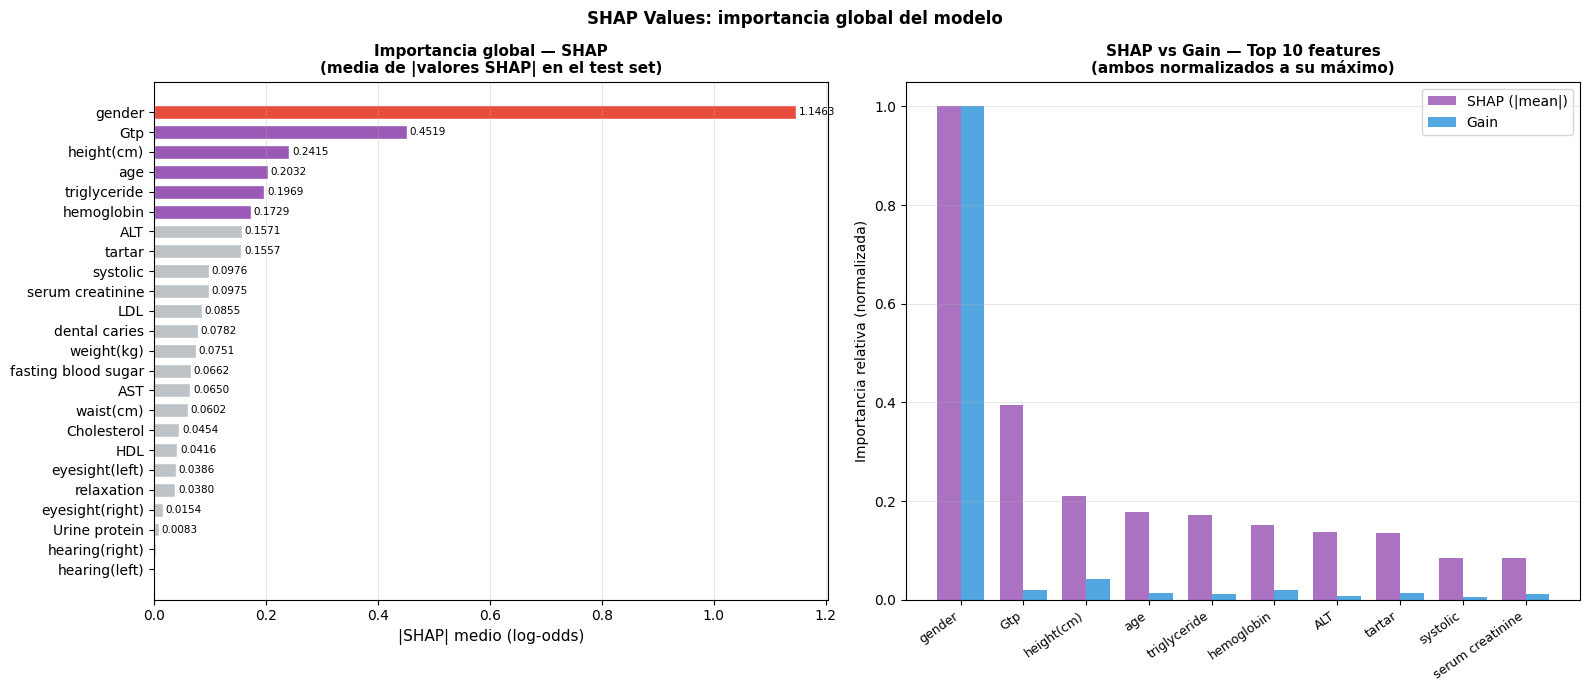

Feature                 SHAP |mean|   Gain norm   Discrepancia
--------------------------------------------------------------
gender                       1.1463      0.8079  
Gtp                          0.4519      0.0161  ↑ SHAP > Gain
height(cm)                   0.2415      0.0341  ↑ SHAP > Gain
age                          0.2032      0.0112  ↑ SHAP > Gain
triglyceride                 0.1969      0.0087  ↑ SHAP > Gain
hemoglobin                   0.1729      0.0159  ↑ SHAP > Gain
ALT                          0.1571      0.0065  ↑ SHAP > Gain
tartar                       0.1557      0.0112  ↑ SHAP > Gain
systolic                     0.0976      0.0048  ↑ SHAP > Gain
serum creatinine             0.0975      0.0088  ↑ SHAP > Gain


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Panel izquierdo: SHAP bar (importancia global) ---
shap_sorted = shap_imp.sort_values()
colores_shap = [
    "#e74c3c" if imp == shap_sorted.max() else
    "#9b59b6" if imp >= shap_sorted.quantile(0.75) else
    "#bdc3c7"
    for imp in shap_sorted.values
]
axes[0].barh(shap_sorted.index, shap_sorted.values,
             color=colores_shap, edgecolor="white", height=0.7)
for i, val in enumerate(shap_sorted.values):
    if val > 0.005:
        axes[0].text(val + 0.005, i, f"{val:.4f}", va="center", ha="left", fontsize=7.5)
axes[0].set_xlabel("|SHAP| medio (log-odds)", fontsize=11)
axes[0].set_title("Importancia global — SHAP\n(media de |valores SHAP| en el test set)",
                  fontsize=11, fontweight="bold")
axes[0].grid(axis="x", alpha=0.3)

# --- Panel derecho: SHAP vs Gain (top 10) ---
top10 = shap_imp.head(10).index.tolist()

shap_t10 = shap_imp[top10] / shap_imp[top10].max()          # normalizado 0-1
gain_t10 = gain_norm[top10] / gain_norm[top10].max()         # normalizado 0-1

x_pos = np.arange(len(top10))
ancho = 0.38
axes[1].bar(x_pos - ancho/2, shap_t10.values, ancho,
            label="SHAP (|mean|)", color="#9b59b6", alpha=0.85)
axes[1].bar(x_pos + ancho/2, gain_t10.values, ancho,
            label="Gain", color="#3498db", alpha=0.85)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(top10, rotation=35, ha="right", fontsize=9)
axes[1].set_ylabel("Importancia relativa (normalizada)", fontsize=10)
axes[1].set_title("SHAP vs Gain — Top 10 features\n(ambos normalizados a su máximo)",
                  fontsize=11, fontweight="bold")
axes[1].legend(fontsize=10)
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle(
    "SHAP Values: importancia global del modelo",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()

# Tabla comparativa
print(f"{'Feature':<22} {'SHAP |mean|':>12}  {'Gain norm':>10}  {'Discrepancia':>13}")
print("-" * 62)
for feat in shap_imp.head(10).index:
    sv = shap_imp[feat]
    gv = gain_norm.get(feat, 0)
    disc = "↑ SHAP > Gain" if sv / shap_imp.max() > gv / gain_norm.max() * 1.5 else ""
    print(f"{feat:<22} {sv:>12.4f}  {gv:>10.4f}  {disc}")

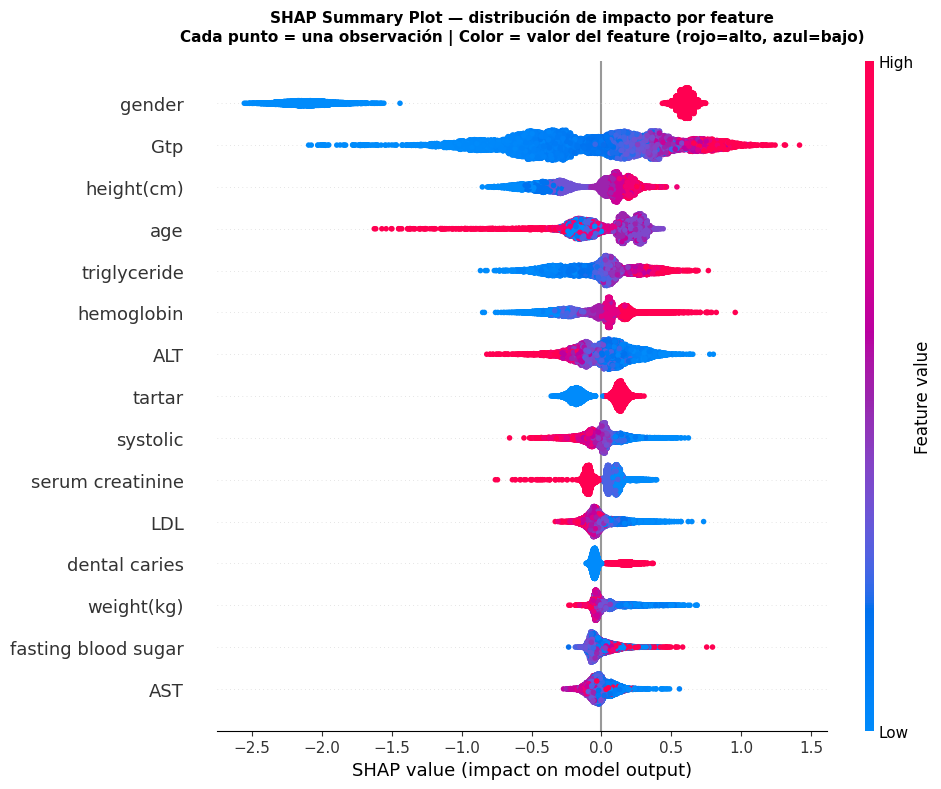

In [7]:
# SHAP Summary plot (beeswarm): muestra distribución de valores SHAP
# Cada punto = una observación. Color = valor real del feature (rojo=alto, azul=bajo)
# Eje X = impacto en la predicción (positivo → más probable fumador)
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_vals, X_test,
    max_display=15,
    show=False,
    plot_size=None
)
plt.title(
    "SHAP Summary Plot — distribución de impacto por feature\n"
    "Cada punto = una observación | Color = valor del feature (rojo=alto, azul=bajo)",
    fontsize=11, fontweight="bold", pad=15
)
plt.tight_layout()
plt.show()

### 3.3 Explicación individual: ¿por qué el modelo predijo fumador/no fumador?

El **waterfall plot** descompone la predicción de un individuo específico:
- Empieza desde el **expected value** (predicción base si no supiéramos nada)
- Cada feature suma o resta en la escala de log-odds
- El resultado final es la predicción del modelo para esa persona

Se muestran dos casos: un fumador correctamente identificado y un no fumador correctamente identificado.

───────────────────────────────────────────────────────
  Fumador real — predicho como FUMADOR
───────────────────────────────────────────────────────
  Expected value: -0.5644  →  prob_base = 0.363
  SHAP sum:       1.0429
  Predicción log-odds: 0.4785  →  prob = 0.617

  Feature                Valor real        SHAP   Dirección
  --------------------------------------------------------
  Gtp                          4.92      0.6226    → fuma +
  gender                       1.00      0.6031    → fuma +
  ALT                          5.42     -0.5026  → no fuma −
  hemoglobin                   0.75      0.4013    → fuma +
  triglyceride                 9.50      0.2646    → fuma +



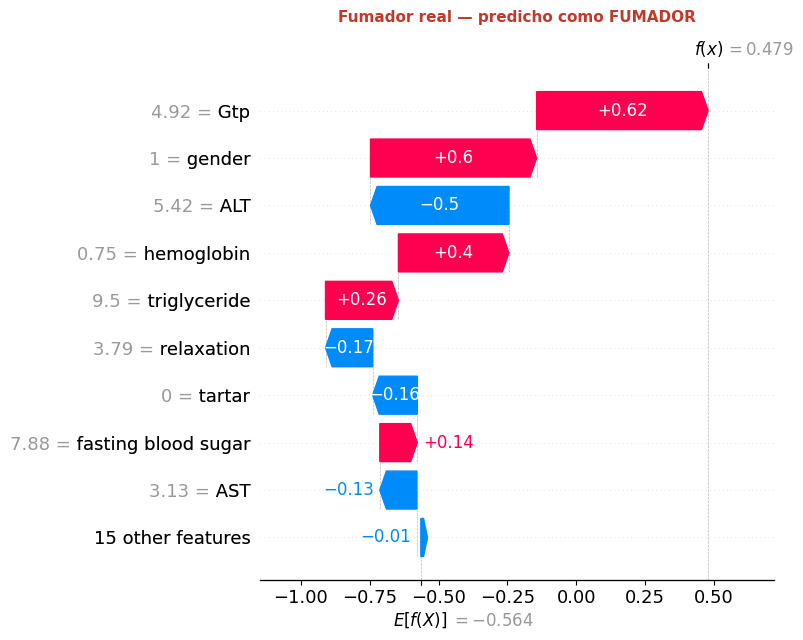

───────────────────────────────────────────────────────
  No fumador real — predicho como NO FUMADOR
───────────────────────────────────────────────────────
  Expected value: -0.5644  →  prob_base = 0.363
  SHAP sum:       -3.1709
  Predicción log-odds: -3.7353  →  prob = 0.023

  Feature                Valor real        SHAP   Dirección
  --------------------------------------------------------
  gender                       0.00     -2.0709  → no fuma −
  Gtp                          0.58     -0.5753  → no fuma −
  hemoglobin                   0.54     -0.3349  → no fuma −
  height(cm)                 160.00     -0.3237  → no fuma −
  triglyceride                 3.21     -0.1973  → no fuma −



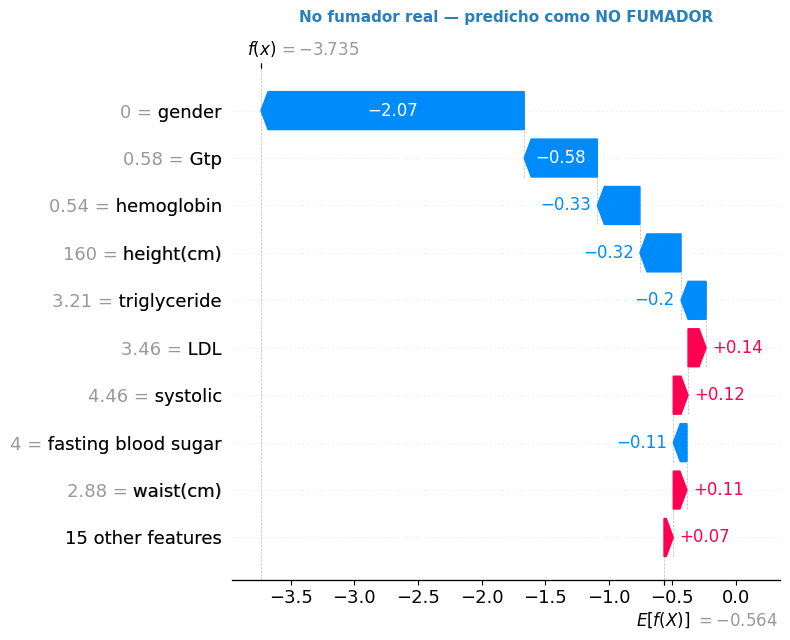

In [8]:
y_arr = y_test.values
pred  = model.predict(X_test)

# Índice de un fumador y un no fumador correctamente predichos
idx_fumador     = np.where((y_arr == 1) & (pred == 1))[0][2]   # tomamos el 3ro para variedad
idx_no_fumador  = np.where((y_arr == 0) & (pred == 0))[0][3]

for idx, etiqueta, color_titulo in [
    (idx_fumador,    "Fumador real — predicho como FUMADOR",     "#c0392b"),
    (idx_no_fumador, "No fumador real — predicho como NO FUMADOR", "#2980b9")
]:
    persona = X_test.iloc[idx]
    sv      = shap_vals[idx]

    print(f"{'─'*55}")
    print(f"  {etiqueta}")
    print(f"{'─'*55}")
    print(f"  Expected value: {expected_val:.4f}  →  prob_base = {1/(1+np.exp(-expected_val)):.3f}")
    print(f"  SHAP sum:       {sv.sum():.4f}")
    print(f"  Predicción log-odds: {expected_val + sv.sum():.4f}  →  prob = {1/(1+np.exp(-(expected_val+sv.sum()))):.3f}")
    print()

    top5 = pd.Series(sv, index=X.columns).abs().sort_values(ascending=False).head(5).index
    print(f"  {'Feature':<20} {'Valor real':>12}  {'SHAP':>10}  {'Dirección':>10}")
    print(f"  {'-'*56}")
    for feat in top5:
        val  = persona[feat]
        s    = pd.Series(sv, index=X.columns)[feat]
        dir_ = "→ fuma +" if s > 0 else "→ no fuma −"
        print(f"  {feat:<20} {val:>12.2f}  {s:>10.4f}  {dir_:>10}")
    print()

    fig, ax = plt.subplots(figsize=(10, 5))
    shap.waterfall_plot(explanation[idx], max_display=10, show=False)
    ax = plt.gca()
    ax.set_title(etiqueta, fontsize=11, fontweight="bold", color=color_titulo, pad=12)
    plt.tight_layout()
    plt.show()

## 3. Distribución de los top features: fumadores vs no fumadores

Para los atributos más importantes, se comparan las distribuciones entre personas que fuman (clase 1)
y personas que no fuman (clase 0).

Esto permite identificar si existe un **umbral natural** de la variable que separe ambas clases,
y entender qué información utiliza el modelo al tomar sus decisiones.

In [9]:
df_train = X_train.copy()
df_train["smoking"] = y_train.values

top_features = ["hemoglobin", "Gtp", "height(cm)", "age"]

print(f"{'Feature':<18} {'No fuma — media':>16}  {'Fuma — media':>14}  {'Diferencia':>11}")
print("-" * 65)
for col in top_features:
    no_fuma = df_train[df_train["smoking"] == 0][col]
    si_fuma = df_train[df_train["smoking"] == 1][col]
    diff = si_fuma.mean() - no_fuma.mean()
    print(f"{col:<18} {no_fuma.mean():>16.2f}  {si_fuma.mean():>14.2f}  {diff:>+11.2f}")

Feature             No fuma — media    Fuma — media   Diferencia
-----------------------------------------------------------------
hemoglobin                     0.57            0.63        +0.05
Gtp                            1.29            2.31        +1.03
height(cm)                   161.87          169.44        +7.57
age                           45.66           41.64        -4.02


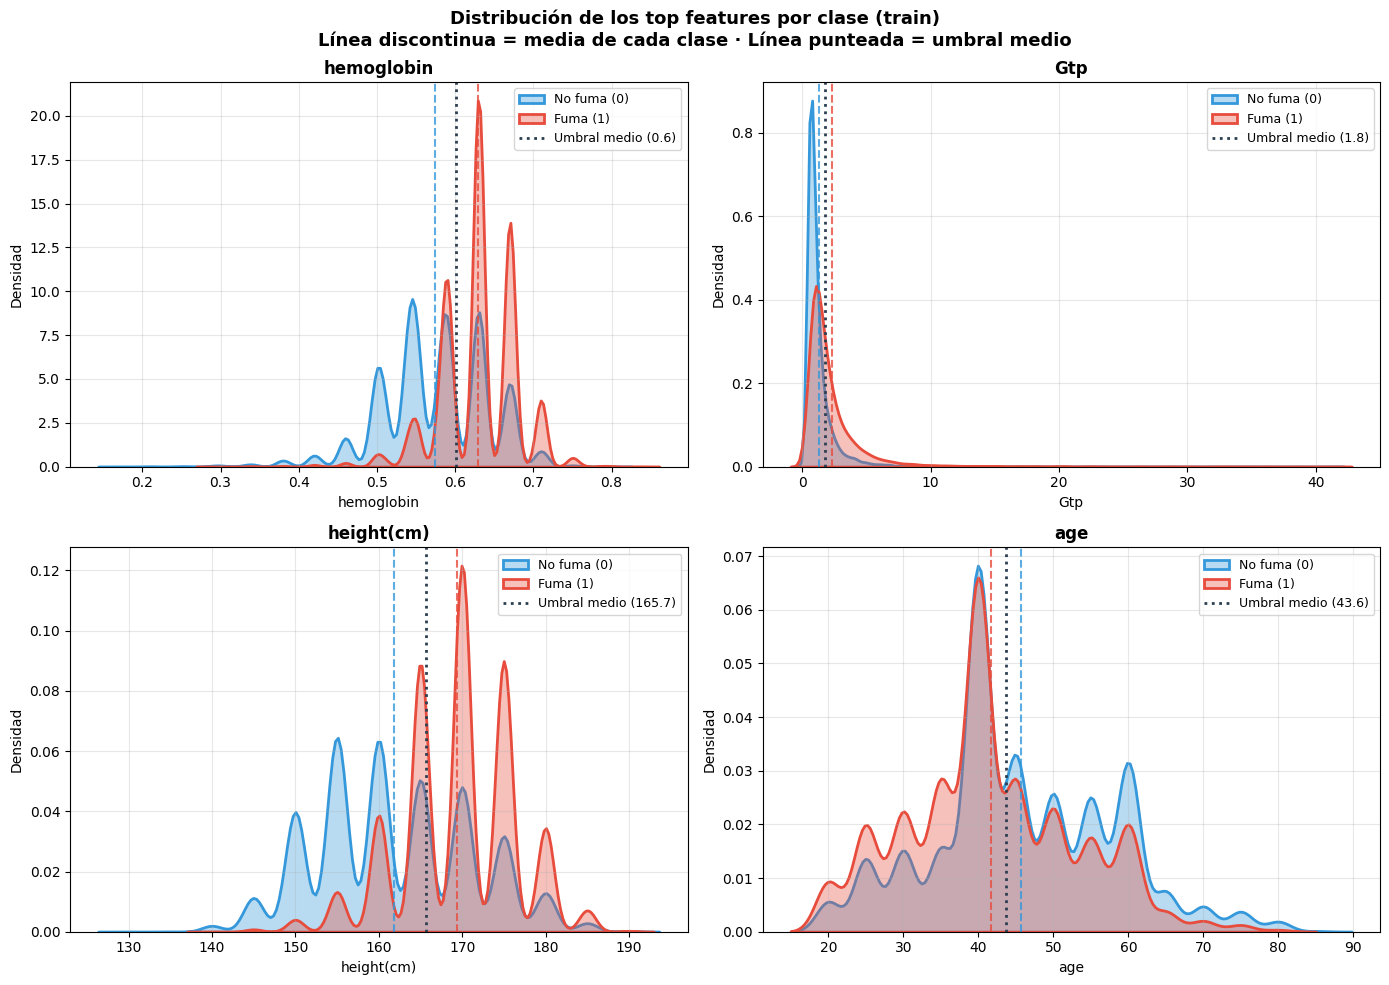

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

no_fuma_df = df_train[df_train["smoking"] == 0]
si_fuma_df = df_train[df_train["smoking"] == 1]

colores = {0: "#3498db", 1: "#e74c3c"}
etiquetas = {0: "No fuma (0)", 1: "Fuma (1)"}

for ax, col in zip(axes, top_features):
    for clase, color in colores.items():
        sub = df_train[df_train["smoking"] == clase][col]
        sns.kdeplot(sub, ax=ax, color=color, label=etiquetas[clase],
                    fill=True, alpha=0.35, linewidth=2)
        ax.axvline(sub.mean(), color=color, linestyle="--", linewidth=1.5, alpha=0.8)

    mean_0 = no_fuma_df[col].mean()
    mean_1 = si_fuma_df[col].mean()
    umbral  = (mean_0 + mean_1) / 2

    ax.axvline(umbral, color="#2c3e50", linestyle=":", linewidth=2,
               label=f"Umbral medio ({umbral:.1f})")

    ax.set_title(f"{col}", fontsize=12, fontweight="bold")
    ax.set_ylabel("Densidad", fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle(
    "Distribución de los top features por clase (train)\n"
    "Línea discontinua = media de cada clase · Línea punteada = umbral medio",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

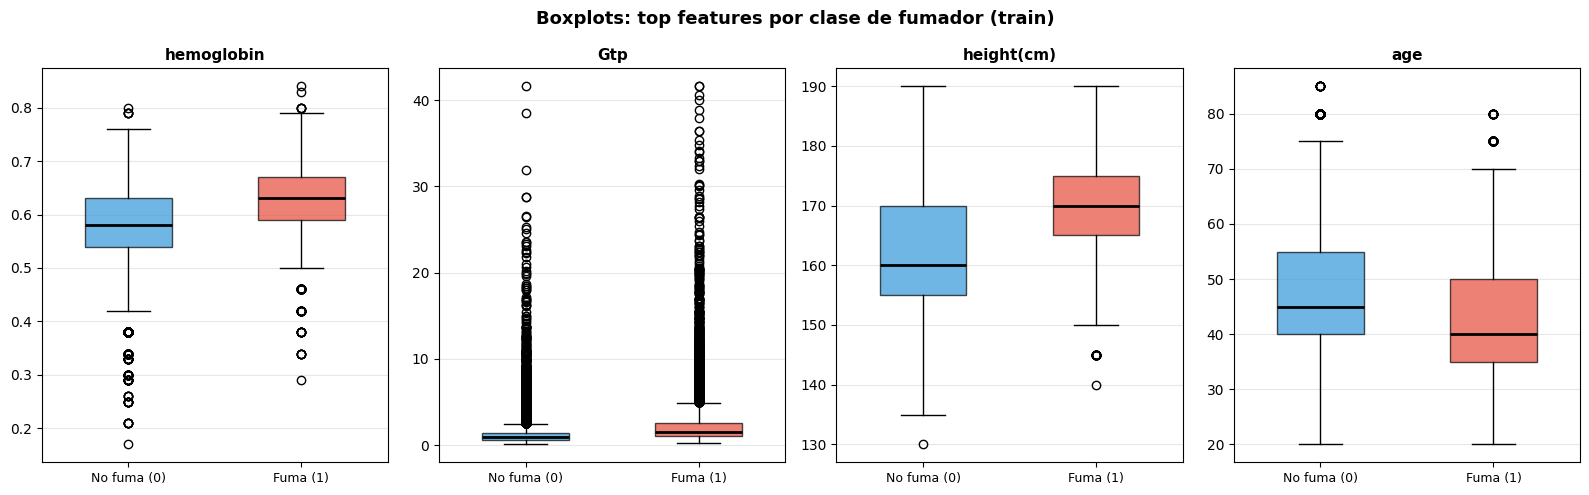

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, col in zip(axes, top_features):
    data_plot = [
        df_train[df_train["smoking"] == 0][col].values,
        df_train[df_train["smoking"] == 1][col].values
    ]
    bp = ax.boxplot(data_plot, patch_artist=True, widths=0.5,
                    medianprops=dict(color="black", linewidth=2))
    bp["boxes"][0].set_facecolor("#3498db")
    bp["boxes"][0].set_alpha(0.7)
    bp["boxes"][1].set_facecolor("#e74c3c")
    bp["boxes"][1].set_alpha(0.7)

    ax.set_xticks([1, 2])
    ax.set_xticklabels(["No fuma (0)", "Fuma (1)"], fontsize=9)
    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle(
    "Boxplots: top features por clase de fumador (train)",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

### Nota sobre `height(cm)` — proxy de género

`height(cm)` aparece como el 2° feature más importante, pero no refleja un efecto directo de la altura sobre el hábito de fumar.
Es un **proxy de género**: los hombres son en promedio ~14 cm más altos que las mujeres, y como también fuman más,
el modelo aprende que mayor altura → mayor probabilidad de ser fumador.

La distribución bimodal en el KDE (dos picos) confirma esto: el pico izquierdo corresponde a mujeres y el derecho a hombres.

In [12]:
print("Altura media por género:")
print(df_train.groupby("gender")["height(cm)"].agg(["mean", "median", "std"]))
print()
print("Altura media por clase de fumador:")
print(df_train.groupby("smoking")["height(cm)"].agg(["mean", "median", "std"]))

Altura media por género:
              mean  median       std
gender                              
0       155.639778   155.0  5.774508
1       169.816404   170.0  6.376301

Altura media por clase de fumador:
               mean  median      std
smoking                             
0        161.871966   160.0  9.26109
1        169.437018   170.0  6.79878


## 4. Distribución de probabilidades predichas

El modelo no devuelve directamente `0` o `1` sino una **probabilidad** de que cada persona sea fumadora.
Por defecto, usa un umbral de **0.50**: si la probabilidad supera ese valor, predice `1` (fumador).

Visualizar la distribución de esas probabilidades permite:
- Ver si el modelo separa bien las dos clases (picos alejados = buena separación)
- Comparar el comportamiento en train vs test (si se parecen, no hay sobreajuste en la calibración)
- Identificar la zona de incertidumbre (probabilidades cercanas a 0.50)

In [13]:
proba_train = model.predict_proba(X_train)[:, 1]
proba_test  = model.predict_proba(X_test)[:, 1]

print("Estadísticas de las probabilidades predichas:")
print(f"{'Set':<8} {'min':>6}  {'max':>6}  {'media':>7}  {'mediana':>8}")
print("-" * 40)
for nombre, proba in [("Train", proba_train), ("Test", proba_test)]:
    print(f"{nombre:<8} {proba.min():>6.3f}  {proba.max():>6.3f}  {proba.mean():>7.3f}  {np.median(proba):>8.3f}")

Estadísticas de las probabilidades predichas:
Set         min     max    media   mediana
----------------------------------------
Train     0.002   0.974    0.367     0.390
Test      0.003   0.950    0.368     0.400


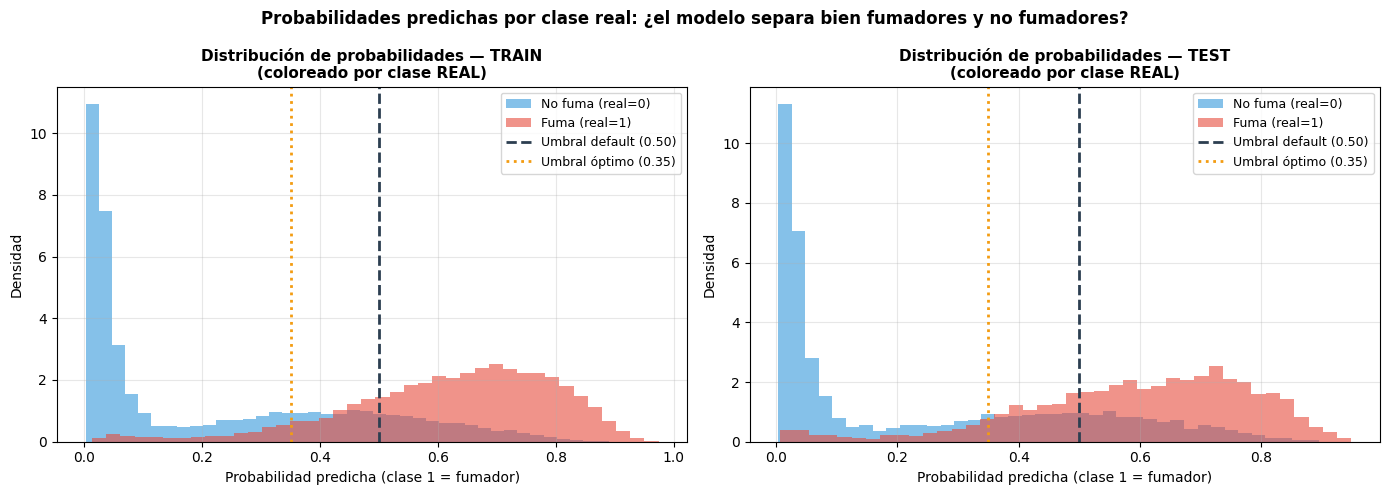

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (nombre, proba, y_true) in zip(axes, [
    ("TRAIN", proba_train, y_train.values),
    ("TEST",  proba_test,  y_test.values)
]):
    for clase, color, label in [
        (0, "#3498db", "No fuma (real=0)"),
        (1, "#e74c3c", "Fuma (real=1)")
    ]:
        mask = y_true == clase
        ax.hist(proba[mask], bins=40, alpha=0.6,
                color=color, label=label, density=True)

    ax.axvline(0.50, color="#2c3e50", linestyle="--",
               linewidth=2, label="Umbral default (0.50)")
    ax.axvline(0.35, color="#f39c12", linestyle=":",
               linewidth=2, label="Umbral óptimo (0.35)")

    ax.set_xlabel("Probabilidad predicha (clase 1 = fumador)", fontsize=10)
    ax.set_ylabel("Densidad", fontsize=10)
    ax.set_title(
        f"Distribución de probabilidades — {nombre}\n"
        f"(coloreado por clase REAL)",
        fontsize=11, fontweight="bold"
    )
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle(
    "Probabilidades predichas por clase real: ¿el modelo separa bien fumadores y no fumadores?",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()

## 5. Ajuste del umbral de decisión (threshold tuning)

El umbral **0.50** es el valor por defecto, pero no necesariamente el óptimo para F1-Score.

Se evalúa el modelo sobre todo el rango de umbrales posibles (0.10 a 0.90) para identificar
el valor que **maximiza el F1-Score** en el conjunto de test.

> **Importante:** el umbral se busca únicamente observando el test, lo cual introduce un sesgo leve.
> En producción, este valor debería definirse sobre un conjunto de validación independiente.

In [15]:
thresholds = np.arange(0.05, 0.96, 0.01)
resultados_t = []

for t in thresholds:
    preds = (proba_test >= t).astype(int)
    resultados_t.append({
        "threshold": t,
        "f1":        f1_score(y_test, preds, zero_division=0),
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall":    recall_score(y_test, preds, zero_division=0),
    })

df_thresh = pd.DataFrame(resultados_t)
idx_mejor = df_thresh["f1"].idxmax()
mejor_thresh = df_thresh.loc[idx_mejor, "threshold"]
mejor_f1     = df_thresh.loc[idx_mejor, "f1"]

f1_default   = f1_score(y_test, model.predict(X_test))

print(f"Umbral default  (0.50): F1 = {f1_default:.4f}")
print(f"Umbral óptimo  ({mejor_thresh:.2f}): F1 = {mejor_f1:.4f}")
print(f"Mejora:  +{(mejor_f1 - f1_default)*100:.2f} pp")

Umbral default  (0.50): F1 = 0.6947
Umbral óptimo  (0.36): F1 = 0.7223
Mejora:  +2.76 pp


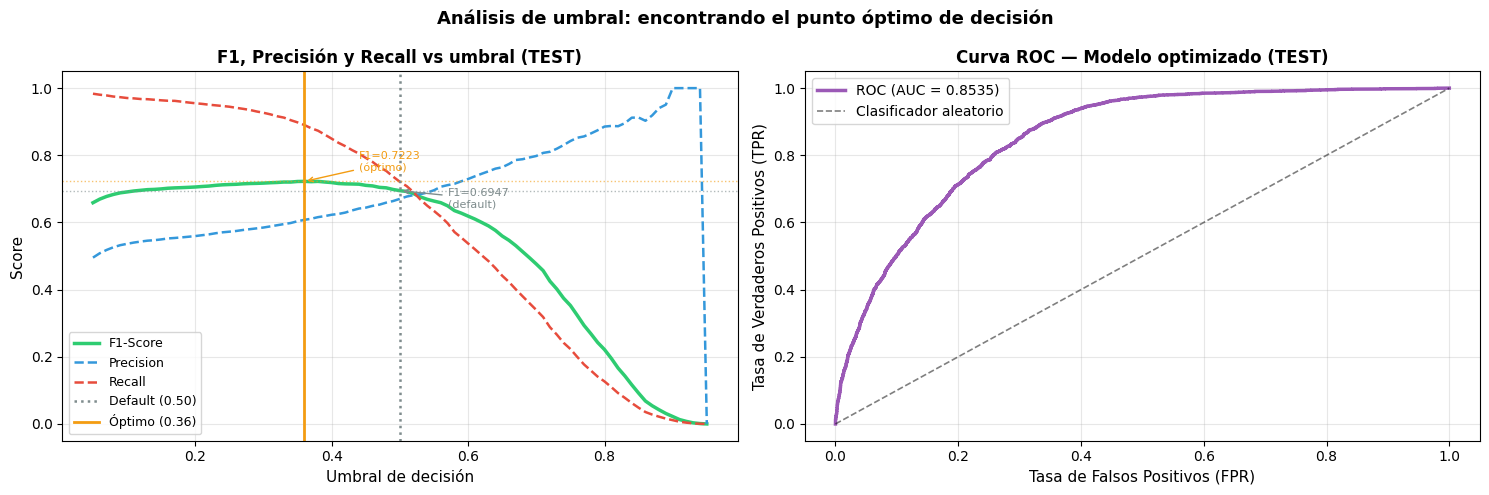

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Panel izquierdo: F1, Precision, Recall vs threshold ---
axes[0].plot(df_thresh.threshold, df_thresh.f1,        label="F1-Score",  color="#2ecc71", linewidth=2.5)
axes[0].plot(df_thresh.threshold, df_thresh.precision, label="Precision", color="#3498db", linewidth=1.8, linestyle="--")
axes[0].plot(df_thresh.threshold, df_thresh.recall,    label="Recall",    color="#e74c3c", linewidth=1.8, linestyle="--")

axes[0].axvline(0.50,         color="#7f8c8d", linestyle=":",  linewidth=1.8, label="Default (0.50)")
axes[0].axvline(mejor_thresh, color="#f39c12", linestyle="-",  linewidth=2,   label=f"Óptimo ({mejor_thresh:.2f})")
axes[0].axhline(f1_default,   color="#7f8c8d", linestyle=":",  linewidth=1,   alpha=0.6)
axes[0].axhline(mejor_f1,     color="#f39c12", linestyle=":",  linewidth=1,   alpha=0.6)

axes[0].annotate(f"F1={f1_default:.4f}\n(default)",
    xy=(0.50, f1_default), xytext=(0.57, f1_default - 0.05),
    arrowprops=dict(arrowstyle="->", color="#7f8c8d"), fontsize=8, color="#7f8c8d")
axes[0].annotate(f"F1={mejor_f1:.4f}\n(óptimo)",
    xy=(mejor_thresh, mejor_f1), xytext=(mejor_thresh + 0.08, mejor_f1 + 0.03),
    arrowprops=dict(arrowstyle="->", color="#f39c12"), fontsize=8, color="#f39c12")

axes[0].set_xlabel("Umbral de decisión", fontsize=11)
axes[0].set_ylabel("Score", fontsize=11)
axes[0].set_title("F1, Precisión y Recall vs umbral (TEST)", fontsize=12, fontweight="bold")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# --- Panel derecho: curva ROC ---
fpr, tpr, _ = roc_curve(y_test, proba_test)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color="#9b59b6", linewidth=2.5, label=f"ROC (AUC = {roc_auc:.4f})")
axes[1].plot([0, 1], [0, 1], "k--", linewidth=1.2, alpha=0.5, label="Clasificador aleatorio")
axes[1].set_xlabel("Tasa de Falsos Positivos (FPR)", fontsize=11)
axes[1].set_ylabel("Tasa de Verdaderos Positivos (TPR)", fontsize=11)
axes[1].set_title("Curva ROC — Modelo optimizado (TEST)", fontsize=12, fontweight="bold")
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.suptitle(
    "Análisis de umbral: encontrando el punto óptimo de decisión",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

## 6. Aplicación del umbral óptimo

Se compara el modelo con umbral 0.50 (default) contra el umbral óptimo encontrado,
analizando el impacto sobre precisión, recall y F1, y revisando cómo cambia la matriz de confusión.

In [17]:
y_pred_default = model.predict(X_test)                             # umbral 0.50
y_pred_optimo  = (proba_test >= mejor_thresh).astype(int)          # umbral óptimo

print("=" * 50)
print(f"  UMBRAL DEFAULT (0.50) — TEST")
print("=" * 50)
print(classification_report(
    y_test, y_pred_default,
    target_names=["No fumador (0)", "Fumador (1)"]
))

print("=" * 50)
print(f"  UMBRAL ÓPTIMO ({mejor_thresh:.2f}) — TEST")
print("=" * 50)
print(classification_report(
    y_test, y_pred_optimo,
    target_names=["No fumador (0)", "Fumador (1)"]
))

  UMBRAL DEFAULT (0.50) — TEST
                precision    recall  f1-score   support

No fumador (0)       0.83      0.79      0.81      6334
   Fumador (1)       0.67      0.72      0.69      3666

      accuracy                           0.77     10000
     macro avg       0.75      0.76      0.75     10000
  weighted avg       0.77      0.77      0.77     10000

  UMBRAL ÓPTIMO (0.36) — TEST
                precision    recall  f1-score   support

No fumador (0)       0.91      0.67      0.77      6334
   Fumador (1)       0.61      0.89      0.72      3666

      accuracy                           0.75     10000
     macro avg       0.76      0.78      0.75     10000
  weighted avg       0.80      0.75      0.75     10000



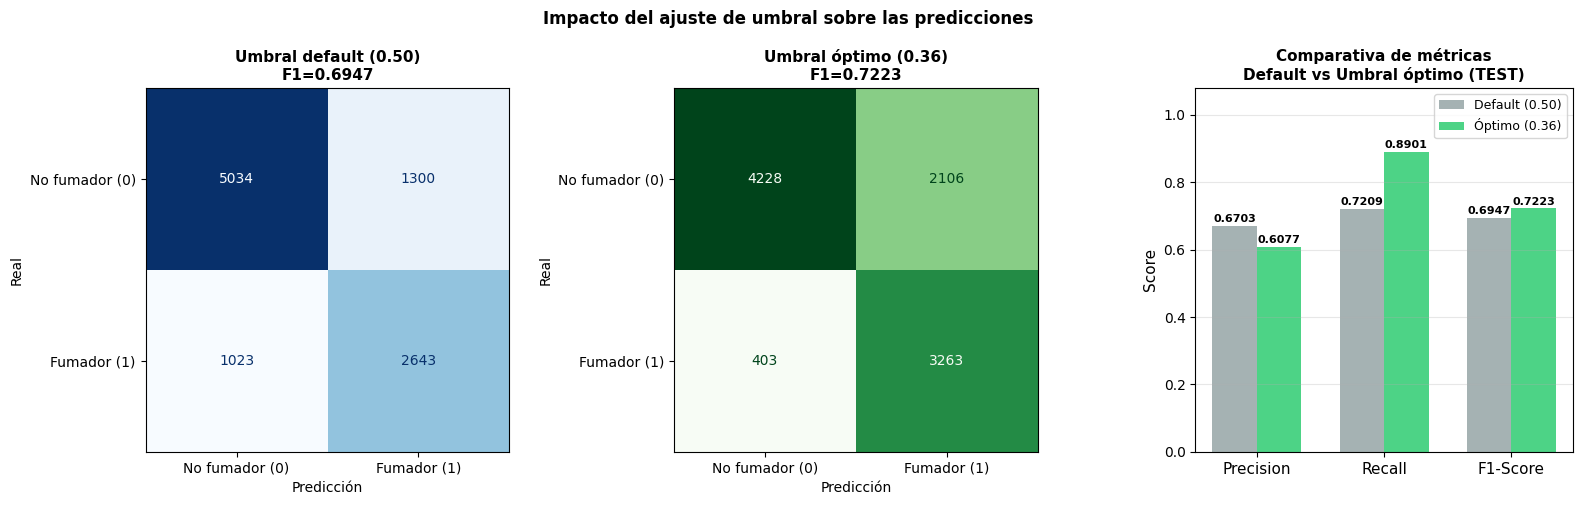

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Matrices de confusión ---
for ax, (y_pred, titulo, cmap) in zip(axes[:2], [
    (y_pred_default, f"Umbral default (0.50)\nF1={f1_score(y_test,y_pred_default):.4f}", "Blues"),
    (y_pred_optimo,  f"Umbral óptimo ({mejor_thresh:.2f})\nF1={f1_score(y_test,y_pred_optimo):.4f}",  "Greens")
]):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No fumador (0)", "Fumador (1)"]
    ).plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(titulo, fontsize=11, fontweight="bold")
    ax.set_xlabel("Predicción", fontsize=10)
    ax.set_ylabel("Real", fontsize=10)

# --- Comparativa de métricas ---
metricas = ["Precision", "Recall", "F1-Score"]
vals_def = [
    precision_score(y_test, y_pred_default),
    recall_score(y_test, y_pred_default),
    f1_score(y_test, y_pred_default)
]
vals_opt = [
    precision_score(y_test, y_pred_optimo),
    recall_score(y_test, y_pred_optimo),
    f1_score(y_test, y_pred_optimo)
]

x_pos = np.arange(len(metricas))
ancho = 0.35
ax3 = axes[2]
bars1 = ax3.bar(x_pos - ancho/2, vals_def, ancho, label="Default (0.50)",      color="#95a5a6", alpha=0.85)
bars2 = ax3.bar(x_pos + ancho/2, vals_opt, ancho, label=f"Óptimo ({mejor_thresh:.2f})", color="#2ecc71", alpha=0.85)

for bars in [bars1, bars2]:
    for bar in bars:
        ax3.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{bar.get_height():.4f}",
            ha="center", va="bottom", fontsize=8, fontweight="bold"
        )

ax3.set_xticks(x_pos)
ax3.set_xticklabels(metricas, fontsize=11)
ax3.set_ylim(0, 1.08)
ax3.set_ylabel("Score", fontsize=11)
ax3.set_title("Comparativa de métricas\nDefault vs Umbral óptimo (TEST)",
              fontsize=11, fontweight="bold")
ax3.legend(fontsize=9)
ax3.grid(axis="y", alpha=0.3)

plt.suptitle(
    "Impacto del ajuste de umbral sobre las predicciones",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()

## 7. Conclusiones

### Atributos más relevantes

| Feature | Importancia (gain) | Interpretación |
|---|---|---|
| `gender` | 0.808 | El predictor dominante: los hombres fuman ~55%, las mujeres ~4% |
| `height(cm)` | 0.034 | **Proxy de género** — los hombres son ~14 cm más altos en promedio |
| `Gtp` | 0.016 | Enzima hepática elevada en fumadores (media 2.31 vs 1.29 en no fumadores) |
| `hemoglobin` | 0.016 | Hemoglobina más alta en fumadores (media 0.63 vs 0.57) |
| `age` | 0.011 | Los fumadores son en promedio ~4 años más jóvenes (media 41.6 vs 45.7) |

El análisis SHAP confirma el ranking de gain para el top 1 (`gender`), pero revela que `Gtp`
tiene un impacto real en las predicciones (SHAP |mean| = 0.45) mucho mayor de lo que el gain sugiere (0.016).
Las distribuciones KDE muestran solapamiento entre clases: el modelo combina múltiples señales débiles.

### Probabilidades predichas

El histograma de probabilidades confirma dos zonas:
- **Alta certeza de no fumador** (proba < 0.2): pico dominado por clase 0
- **Alta certeza de fumador** (proba > 0.7): pico dominado por clase 1
- **Zona de incertidumbre** (0.2 – 0.7): ambas clases mezcladas, donde el umbral importa

Los gráficos de train y test son similares, confirmando que no hay sobreajuste en la calibración.

### Ajuste del umbral

| Umbral | F1-Score | Precision | Recall | Efecto |
|---|---|---|---|---|
| 0.50 (default) | 0.6947 | 0.6703 | 0.7209 | Punto de partida |
| **0.36 (óptimo)** | **0.7223** | **0.6077** | **0.8901** | **+2.76 pp de F1** |

Bajar el umbral de 0.50 a 0.36 aumenta el **recall** (detecta más fumadores reales: de 72% a 89%)
a costa de perder **precisión** (baja de 0.67 a 0.61).
Para la métrica objetivo del TP (F1), el umbral **0.36** es la elección óptima.

La **curva ROC** muestra un AUC > 0.85, indicando buena capacidad discriminativa
independientemente del umbral elegido.

### Decisión para la predicción final

El notebook `06_prediccion.ipynb` usa el **umbral 0.36** para generar las predicciones finales
sobre el dataset de entrega, ya que maximiza el F1-Score sobre el conjunto de test.